In [62]:
# importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches



In [63]:
# loading the dataset
df = pd.read_csv('Datasets/final-segment-dataset-2025.csv')

In [64]:

df.head()

,rid,from_station,to_station,late_canc_reason,total_stops_in_run,remaining_stops_after_this,date_of_service,month,day_of_week,day_of_month,...,historical_avg_leg_duration_min,historical_avg_cum_delay_min,historical_avg_arrival_delay_min,delay_historical_difference,from_temp,from_precip,from_wind,to_temp,to_precip,to_wind
0,2.025010e+14,KGX,YRK,696.0,6,5,01/01/2025,1,2,1,...,106.655367,-62.201977,-65.834746,61.201977,6.1,0.8,17.0,4.1,0.0,17.9
1,2.025010e+14,KGX,YRK,NaN,6,5,01/01/2025,1,2,1,...,106.655367,-62.201977,-65.834746,61.201977,5.9,1.2,16.9,3.9,0.0,17.2
2,2.025010e+14,KGX,YRK,NaN,6,5,01/01/2025,1,2,1,...,106.655367,-62.201977,-65.834746,61.201977,6.2,0.2,14.9,3.4,0.0,15.4
3,2.025010e+14,KGX,YRK,NaN,6,5,02/01/2025,1,3,2,...,106.655367,-62.201977,-65.834746,61.201977,3.1,0.0,8.1,0.2,0.0,11.0
4,2.025010e+14,KGX,YRK,NaN,6,5,02/01/2025,1,3,2,...,106.655367,-62.201977,-65.834746,61.201977,2.4,0.0,6.7,0.0,0.0,12.3


In [65]:
df.columns

Index(['rid', 'from_station', 'to_station', 'late_canc_reason',
       'total_stops_in_run', 'remaining_stops_after_this', 'date_of_service',
       'month', 'day_of_week', 'day_of_month', 'from_sched_arrival_min',
       'from_actual_arrival_min', 'from_sched_departure_min',
       'from_actual_departure_min', 'to_sched_arrival_min',
       'to_actual_arrival_min', 'to_sched_departure_min',
       'to_actual_departure_min', 'propagated_delay_min',
       'end_segment_delay_min', 'cum_delay_min', 'leg_duration_min',
       'arrival_delay_min', 'prev_train_leg_delay_min',
       'prev_train_cum_delay_min', 'prev_train_segment_duration_min',
       'prev_train_end_segment_delay_min',
       'historical_avg_propagated_delay_min',
       'historical_avg_leg_duration_min', 'historical_avg_cum_delay_min',
       'historical_avg_arrival_delay_min', 'delay_historical_difference',
       'from_temp', 'from_precip', 'from_wind', 'to_temp', 'to_precip',
       'to_wind'],
      dtype='object')

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   rid                                  11195 non-null  float64
 1   from_station                         11195 non-null  object 
 2   to_station                           11195 non-null  object 
 3   late_canc_reason                     3721 non-null   float64
 4   total_stops_in_run                   11195 non-null  int64  
 5   remaining_stops_after_this           11195 non-null  int64  
 6   date_of_service                      11195 non-null  object 
 7   month                                11195 non-null  int64  
 8   day_of_week                          11195 non-null  int64  
 9   day_of_month                         11195 non-null  int64  
 10  from_sched_arrival_min               11195 non-null  int64  
 11  from_actual_arrival_min     

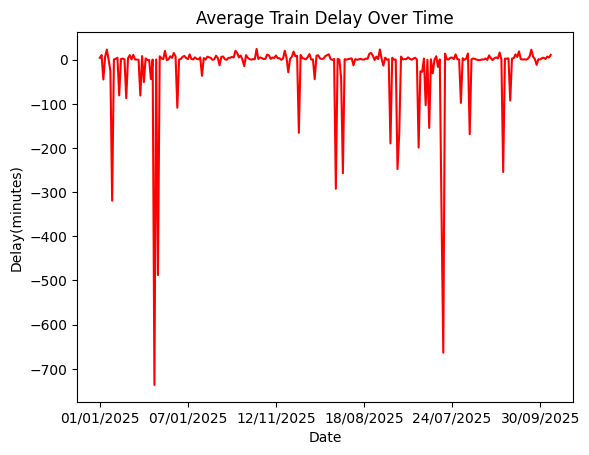

In [67]:


# grouping by date and get average delays
delay_time = df.groupby('date_of_service')['arrival_delay_min'].mean()

# plot
plt.figure()
delay_time.plot(color = 'red')
plt.title('Average Train Delay Over Time')
plt.xlabel('Date')
plt.ylabel('Delay(minutes)')
plt.show()

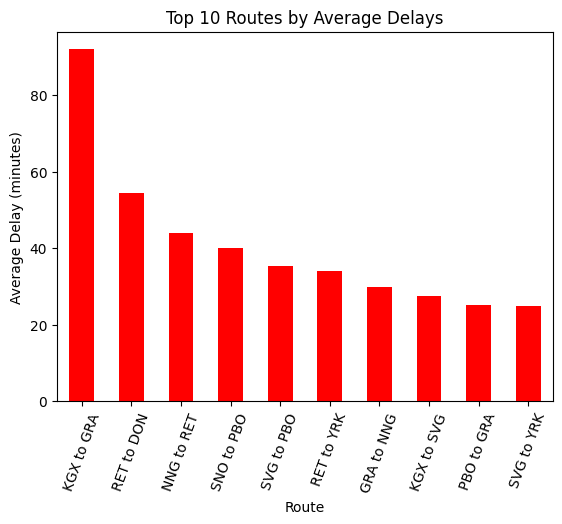

In [68]:

# a route column
df['route'] = df['from_station'] + " to " + df['to_station']

# average delays per route
route_delay = df.groupby('route')['arrival_delay_min'].mean().sort_values(ascending=False).head(10)

#plot
plt.figure()
route_delay.plot(kind='bar', color='red')
plt.title('Top 10 Routes by Average Delays')
plt.xlabel('Route')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=70)
plt.show()


C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


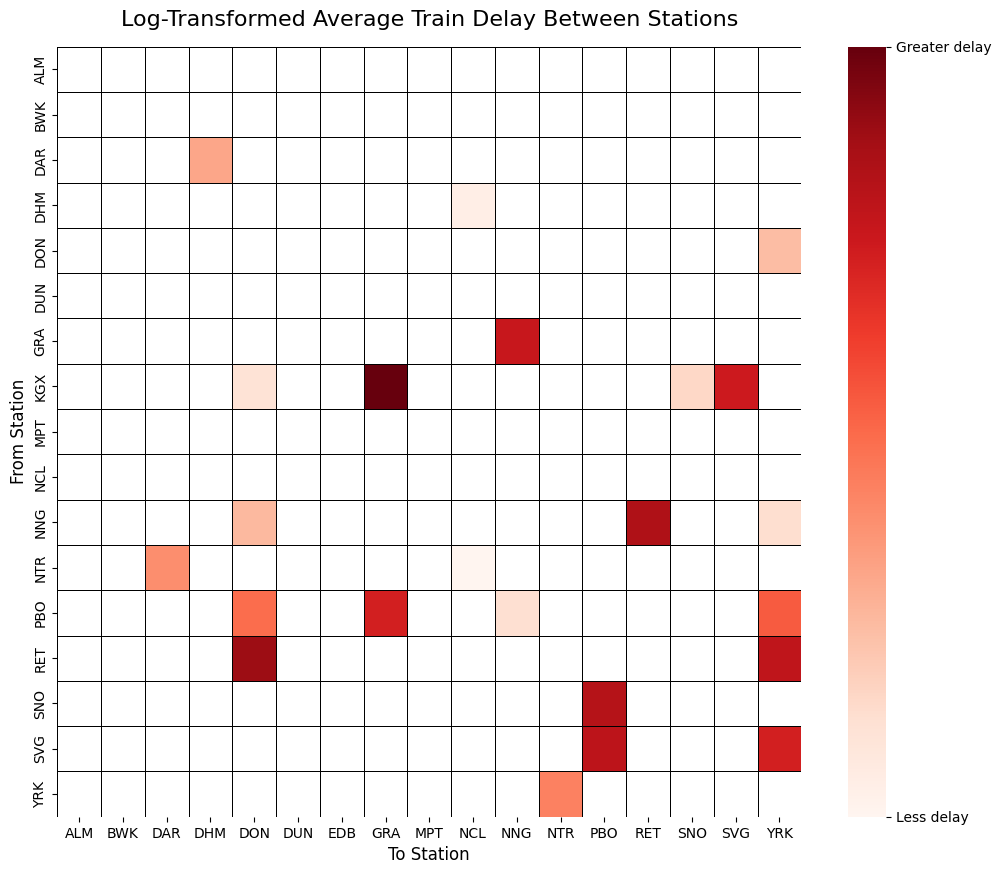

In [69]:
# average delays per route
route_matrix = df.groupby(['from_station','to_station'])['arrival_delay_min'].mean().reset_index()

heatmap_data = route_matrix.pivot(index = 'from_station', columns = 'to_station', values = 'arrival_delay_min')
log_heatmap_data = np.log1p(heatmap_data+1)  # log transformation to handle skewness and improve visualization

plt.figure(figsize=(12,10))

ax = sns.heatmap(
    log_heatmap_data,
    cmap='Reds',
    linewidths=0.5,
    linecolor='black'
)

# Customize colorbar
cbar = ax.collections[0].colorbar
cbar.set_ticks([
    log_heatmap_data.min().min(),
    log_heatmap_data.max().max()
])
cbar.set_ticklabels(['Less delay', 'Greater delay'])

plt.title('Log-Transformed Average Train Delay Between Stations', fontsize=16, pad=15)
plt.xlabel('To Station', fontsize=12)
plt.ylabel('From Station', fontsize=12)
plt.show()



(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0, 0.5, 'RET'),
  Text(0, 1.5, 'SNO'),
  Text(0, 2.5, 'SVG'),
  Text(0, 3.5, 'NTR'),
  Text(0, 4.5, 'DON'),
  Text(0, 5.5, 'NNG'),
  Text(0, 6.5, 'PBO'),
  Text(0, 7.5, 'DHM'),
  Text(0, 8.5, 'DAR'),
  Text(0, 9.5, 'YRK')])

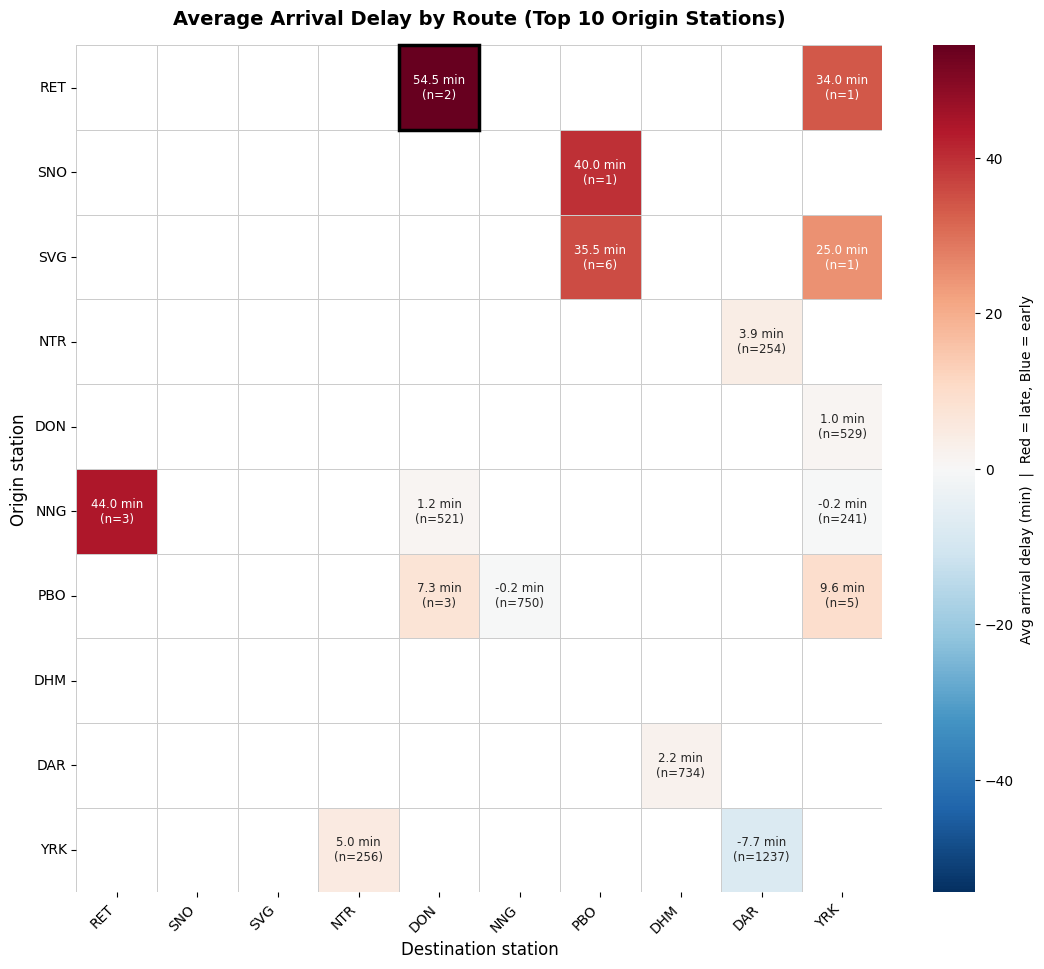

In [70]:
# Calculate average delay and number of journeys for each route
route_stats = df.groupby(['from_station', 'to_station'])['arrival_delay_min'].agg(
    mean_delay='mean',
    n='count'
).reset_index()

# Pivot into matrix format for the heatmap
delay_matrix = route_stats.pivot(index='from_station', columns='to_station', values='mean_delay')
count_matrix = route_stats.pivot(index='from_station', columns='to_station', values='n')

# Order stations by their average delay (worst first)
station_order = (
    df.groupby('from_station')['arrival_delay_min']
    .mean()
    .sort_values(ascending=False)
    .index
)

#  only stations that appear in both axes, take top 10
station_order = [s for s in station_order if s in delay_matrix.index and s in delay_matrix.columns]
delay_matrix = delay_matrix.loc[station_order[:10], station_order[:10]]
count_matrix = count_matrix.reindex(index=delay_matrix.index, columns=delay_matrix.columns)

# Build annotation labels showing delay + sample size
annot = pd.DataFrame('', index=delay_matrix.index, columns=delay_matrix.columns)
for r in delay_matrix.index:
    for c in delay_matrix.columns:
        val = delay_matrix.loc[r, c]
        if pd.notna(val):
            n = count_matrix.loc[r, c]
            annot.loc[r, c] = f"{val:.1f} min\n(n={int(n)})"

# Plot
fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    delay_matrix,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-np.nanmax(np.abs(delay_matrix.values)),
    vmax=np.nanmax(np.abs(delay_matrix.values)),
    linewidths=0.5,
    linecolor='#cccccc',
    annot=annot,
    fmt='',
    annot_kws={'fontsize': 8.5},
    cbar_kws={'label': 'Avg arrival delay (min)  |  Red = late, Blue = early'}
)

# Highlight the worst route with a border
worst_pos = np.unravel_index(np.nanargmax(delay_matrix.values), delay_matrix.shape)
ax.add_patch(mpatches.Rectangle(
    (worst_pos[1], worst_pos[0]), 1, 1,
    fill=False, edgecolor='black', lw=2.5, clip_on=False
))

# Labels and title
ax.set_title('Average Arrival Delay by Route (Top 10 Origin Stations)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Destination station', fontsize=12)
ax.set_ylabel('Origin station', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)




(-0.5, 5.3)

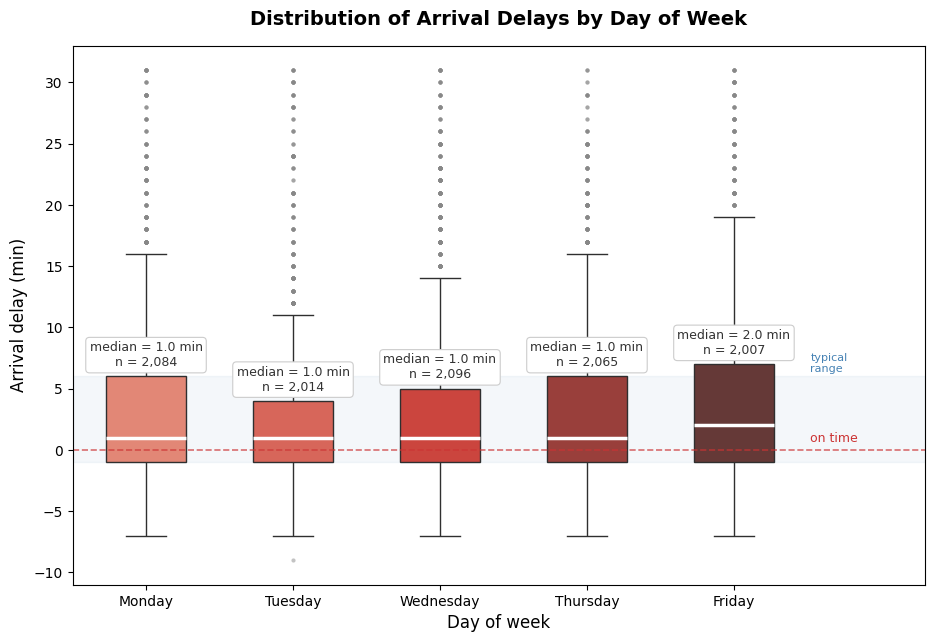

In [71]:

# Map day numbers to names
day_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday'}
df['day_of_week_name'] = df['day_of_week'].map(day_map)

# Remove outliers using 3×IQR method
Q1 = df['arrival_delay_min'].quantile(0.25)
Q3 = df['arrival_delay_min'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

df_filtered = df[
    (df['arrival_delay_min'] >= lower) &
    (df['arrival_delay_min'] <= upper) &
    (df['day_of_week_name'].notna())
].copy()

n_removed = len(df) - len(df_filtered)
pct_removed = 100 * n_removed / len(df)

# Calculate median and count per day for annotations
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
day_stats = df_filtered.groupby('day_of_week_name')['arrival_delay_min'].agg(
    median='median',
    q3=lambda x: x.quantile(0.75),
    n='count'
).reindex(day_order)

# Plot
fig, ax = plt.subplots(figsize=(11, 7))

sns.boxplot(
    data=df_filtered,
    x='day_of_week_name',
    y='arrival_delay_min',
    order=day_order,
    hue='day_of_week_name',
    hue_order=day_order,
    palette='Reds_d',
    width=0.55,
    legend=False,
    flierprops=dict(marker='o', markersize=3, markerfacecolor='#888888',
                    markeredgecolor='none', alpha=0.5),
    medianprops=dict(color='white', linewidth=2.5),
    ax=ax
)

# Add median and sample size label above each box
for i, day in enumerate(day_order):
    med = day_stats.loc[day, 'median']
    q3val = day_stats.loc[day, 'q3']
    n = int(day_stats.loc[day, 'n'])
    ax.text(i, q3val + 0.6, f'median = {med:.1f} min\nn = {n:,}',
            ha='center', va='bottom', fontsize=9, color='#333333',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#cccccc', linewidth=0.8))

# Add a red dashed line at zero to show the on-time threshold
ax.axhline(0, color='#cc3333', linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(4.52, 0.4, 'on time', color='#cc3333', fontsize=9, va='bottom')

# Shade the typical delay range (overall IQR)
overall_q1 = df_filtered['arrival_delay_min'].quantile(0.25)
overall_q3 = df_filtered['arrival_delay_min'].quantile(0.75)
ax.axhspan(overall_q1, overall_q3, alpha=0.06, color='steelblue')
ax.text(4.52, overall_q3 + 0.2, 'typical\nrange', color='steelblue', fontsize=8, va='bottom')

# Titles and axis labels
ax.set_title('Distribution of Arrival Delays by Day of Week',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day of week', fontsize=12)
ax.set_ylabel('Arrival delay (min)', fontsize=12)
ax.set_xlim(-0.5, 5.3)



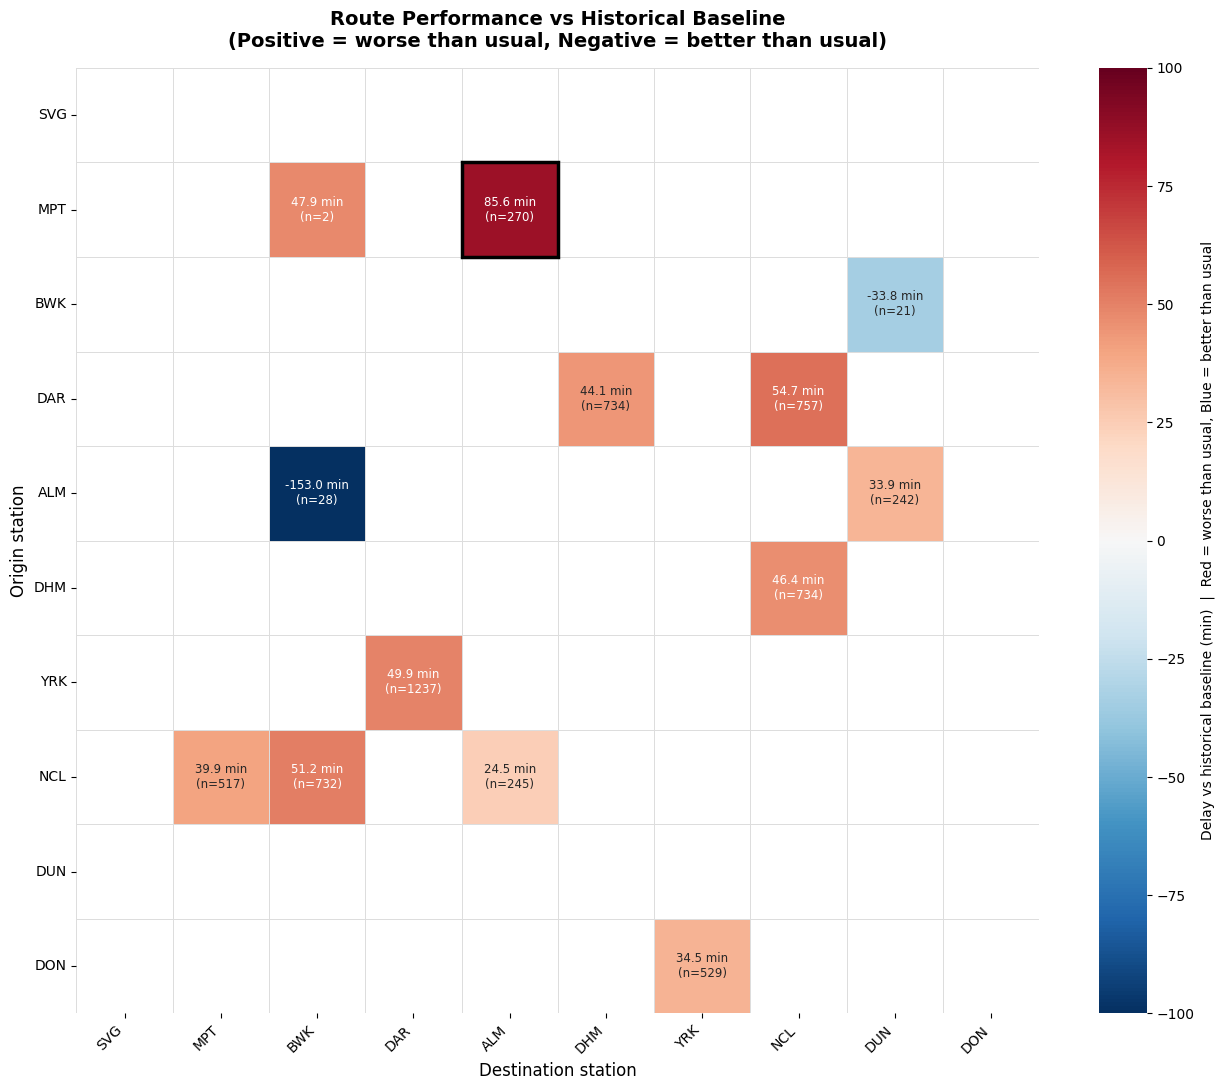

In [72]:
# Calculate mean historical difference and journey count per route
route_stats = df.groupby(['from_station', 'to_station'])['delay_historical_difference'].agg(
    mean_diff='mean',
    n='count'
).reset_index()

# Remove extreme values that are likely data errors (beyond ±500 min)
route_clean = route_stats[route_stats['mean_diff'].abs() <= 500].copy()

# Pivot into matrix format
delay_matrix = route_clean.pivot(index='from_station', columns='to_station', values='mean_diff')
count_matrix = route_clean.pivot(index='from_station', columns='to_station', values='n')

# Order stations by worst average historical difference, take top 10
station_order = (
    df.groupby('from_station')['delay_historical_difference']
    .mean()
    .sort_values(ascending=False)
    .index
)
station_order = [s for s in station_order if s in delay_matrix.index and s in delay_matrix.columns]
delay_matrix = delay_matrix.loc[station_order[:10], station_order[:10]]
count_matrix = count_matrix.reindex(index=delay_matrix.index, columns=delay_matrix.columns)

# Build annotation labels with delay value and sample size
annot = pd.DataFrame('', index=delay_matrix.index, columns=delay_matrix.columns)
for r in delay_matrix.index:
    for c in delay_matrix.columns:
        val = delay_matrix.loc[r, c]
        if pd.notna(val):
            n = count_matrix.loc[r, c]
            annot.loc[r, c] = f'{val:.1f} min\n(n={int(n)})'

# Plot, cap colour scale at ±100 so moderate differences are still visible
fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    delay_matrix,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-100,
    vmax=100,
    linewidths=0.5,
    linecolor='#dddddd',
    annot=annot,
    fmt='',
    annot_kws={'fontsize': 8.5},
    cbar_kws={'label': 'Delay vs historical baseline (min)  |  Red = worse than usual, Blue = better than usual'}
)

# Highlight the worst route with at least 10 observations
worst_val = -np.inf
worst_pos = None
for i, r in enumerate(delay_matrix.index):
    for j, c in enumerate(delay_matrix.columns):
        val = delay_matrix.loc[r, c]
        n = count_matrix.loc[r, c] if pd.notna(count_matrix.loc[r, c]) else 0
        if pd.notna(val) and n >= 10 and val > worst_val:
            worst_val = val
            worst_pos = (i, j)

if worst_pos:
    ax.add_patch(mpatches.Rectangle(
        (worst_pos[1], worst_pos[0]), 1, 1,
        fill=False, edgecolor='black', lw=2.5, clip_on=False
    ))

# Title and axis labels
ax.set_title(
    'Route Performance vs Historical Baseline\n(Positive = worse than usual, Negative = better than usual)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Destination station', fontsize=12)
ax.set_ylabel('Origin station', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

(-0.5, 5.2)

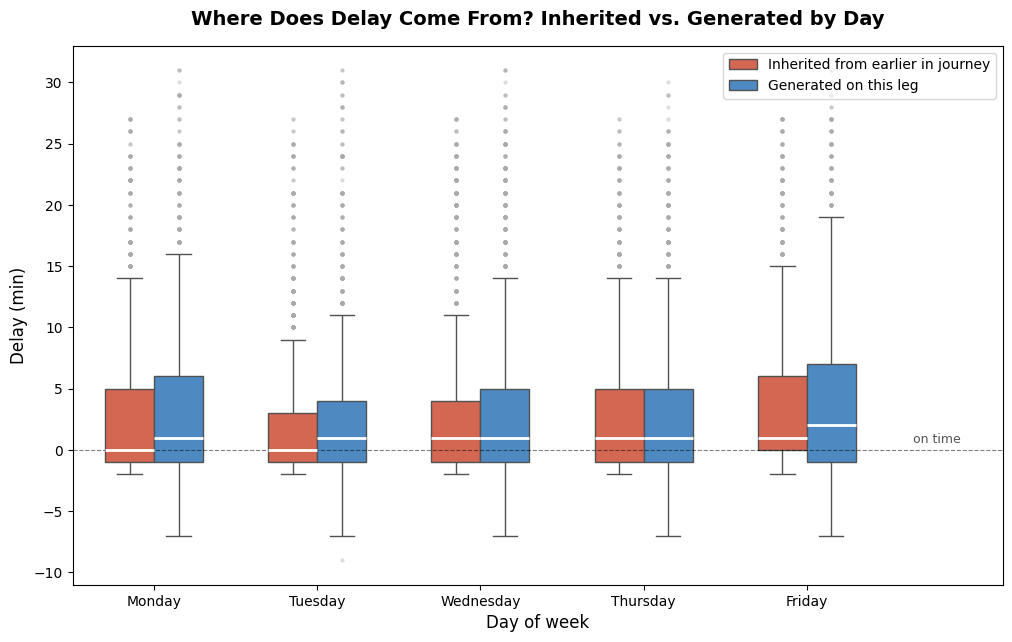

In [73]:
# Map day numbers to names
day_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday'}
df['day_of_week_name'] = df['day_of_week'].map(day_map)

# Filter each delay column independently using 3×IQR
# clean all three columns, not just arrival_delay_min
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 3 * IQR, Q3 + 3 * IQR

arr_lower, arr_upper = iqr_bounds(df['arrival_delay_min'])
prop_lower, prop_upper = iqr_bounds(df['propagated_delay_min'])
seg_lower, seg_upper = iqr_bounds(df['end_segment_delay_min'])

df_filtered = df[
    (df['arrival_delay_min'].between(arr_lower, arr_upper)) &
    (df['propagated_delay_min'].between(prop_lower, prop_upper)) &
    (df['end_segment_delay_min'].between(seg_lower, seg_upper)) &
    (df['day_of_week_name'].notna())
].copy()

n_removed = len(df) - len(df_filtered)
pct_removed = 100 * n_removed / len(df)

# Reshape to long format for side-by-side boxplot
df_melt = df_filtered.melt(
    id_vars=['day_of_week_name'],
    value_vars=['propagated_delay_min', 'end_segment_delay_min'],
    var_name='Delay Type',
    value_name='Minutes'
)

df_melt['Delay Type'] = df_melt['Delay Type'].map({
    'propagated_delay_min': 'Inherited from earlier in journey',
    'end_segment_delay_min': 'Generated on this leg'
})

# Plot
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_melt,
    x='day_of_week_name',
    y='Minutes',
    hue='Delay Type',
    order=day_order,
    palette=['#E8593C', '#3B8BD4'],
    width=0.6,
    flierprops=dict(marker='o', markersize=3, markerfacecolor='#aaaaaa',
                    markeredgecolor='none', alpha=0.4),
    medianprops=dict(color='white', linewidth=2),
    ax=ax
)

# Zero reference line
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(4.65, 0.3, 'on time', fontsize=9, color='#555555', va='bottom')

# Titles and labels
ax.set_title('Where Does Delay Come From? Inherited vs. Generated by Day',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day of week', fontsize=12)
ax.set_ylabel('Delay (min)', fontsize=12)
ax.legend(title='', fontsize=10, loc='upper right')
ax.set_xlim(-0.5, 5.2)



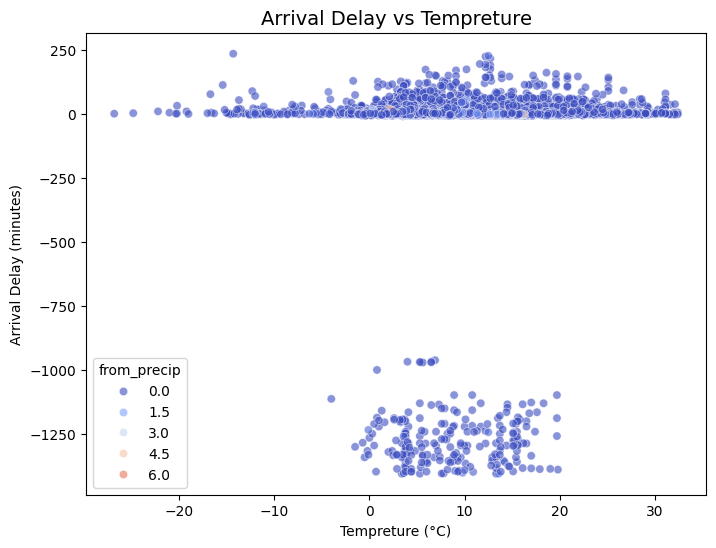

In [74]:
# delay vs tempreture
plt.figure(figsize = (8,6))
sns.scatterplot(
    data = df,
    x = 'from_temp',
    y = 'arrival_delay_min',
    hue = 'from_precip',
    palette = 'coolwarm',
    alpha = 0.6
)

plt.title("Arrival Delay vs Tempreture", fontsize = 14)
plt.xlabel("Tempreture (°C)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()


Text(0.5, 1.02, 'Does Rain Cause Delays?')

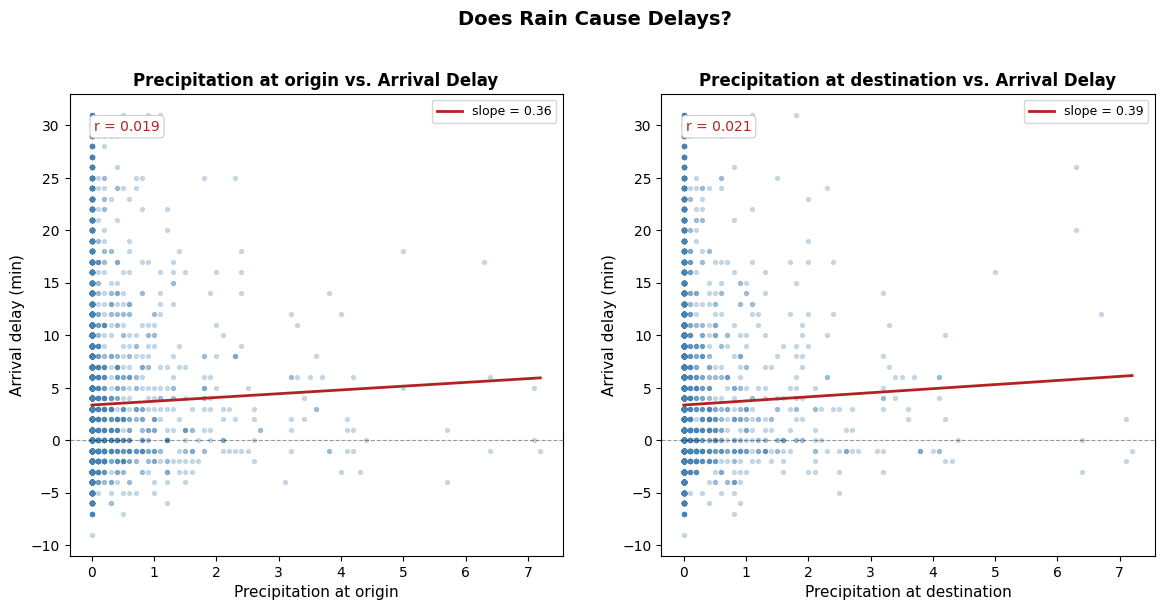

In [75]:
# Reuse the same filtered dataframe from previous chart box plot
# reapply the filter:
df_plot = df_filtered.copy()

# Calculate how many points were removed for the footnote
n_removed = len(df) - len(df_plot)
pct_removed = 100 * n_removed / len(df)

# Plot scatter with regression line for rain at origin and destination
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rain_cols = [('from_precip', 'Precipitation at origin'), ('to_precip', 'Precipitation at destination')]

for ax, (col, label) in zip(axes, rain_cols):

    # Scatter plot
    ax.scatter(
        df_plot[col], df_plot['arrival_delay_min'],
        alpha=0.25, s=8, color='steelblue'
    )

    # Fit and draw regression line
    x = df_plot[col].fillna(0)
    y = df_plot['arrival_delay_min'].fillna(0)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='firebrick', linewidth=2, label=f'slope = {m:.2f}')

    # Zero delay reference line
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)

    # Calculate Pearson correlation to quantify the relationship
    r = df_plot[[col, 'arrival_delay_min']].dropna().corr().iloc[0, 1]

    # Add correlation value directly onto the chart
    ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
            fontsize=10, color='firebrick',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#cccccc', linewidth=0.8))

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Arrival delay (min)', fontsize=11)
    ax.set_title(f'{label} vs. Arrival Delay', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Does Rain Cause Delays?', fontsize=14, fontweight='bold', y=1.02)



(15.5, 22.5)

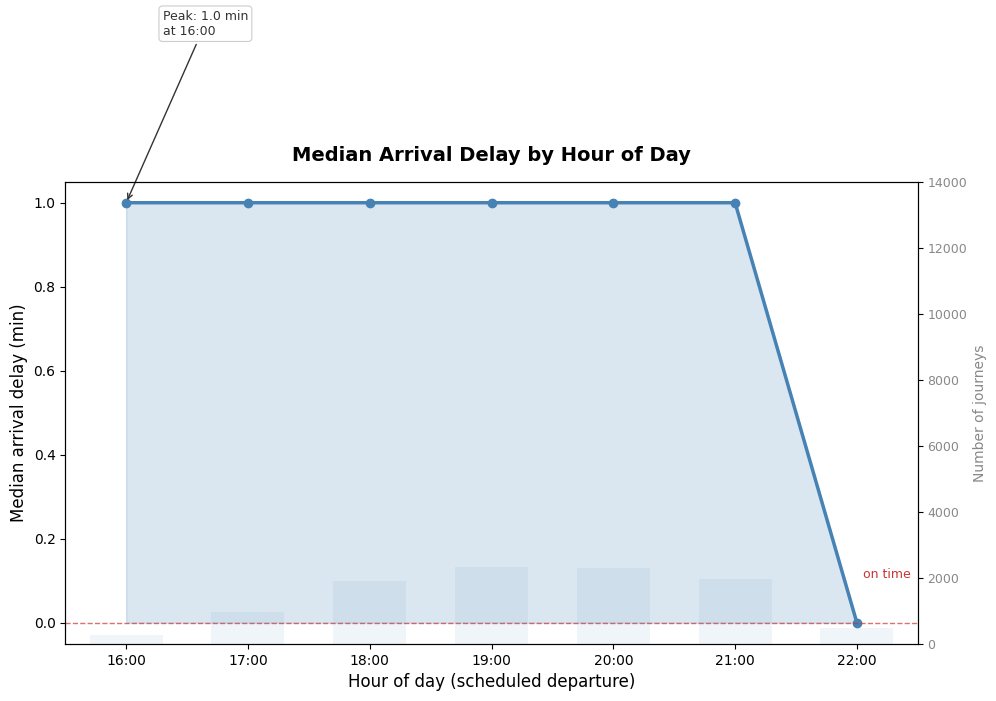

In [76]:
# Extract scheduled hour: data runs 16:00 to 22:00 only
df_filtered['sched_hour'] = (df_filtered['from_sched_departure_min'] // 60).astype(int)
df_hours = df_filtered[df_filtered['sched_hour'].between(16, 22)].copy()

# Calculate median delay and journey count per hour
hourly = df_hours.groupby('sched_hour')['arrival_delay_min'].agg(
    median='median',
    n='count'
).reset_index()

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(hourly['sched_hour'], hourly['median'], alpha=0.2, color='steelblue')
ax.plot(hourly['sched_hour'], hourly['median'], color='steelblue',
        linewidth=2.5, marker='o', markersize=6)

# Zero reference line
ax.axhline(0, color='#cc3333', linewidth=1, linestyle='--', alpha=0.7)
ax.text(22.05, 0.1, 'on time', color='#cc3333', fontsize=9, va='bottom')

# Highlight peak delay hour
peak_hour = hourly.loc[hourly['median'].idxmax(), 'sched_hour']
peak_val  = hourly.loc[hourly['median'].idxmax(), 'median']
ax.annotate(
    f'Peak: {peak_val:.1f} min\nat {peak_hour}:00',
    xy=(peak_hour, peak_val),
    xytext=(peak_hour + 0.3, peak_val + 0.4),
    fontsize=9, color='#333333',
    arrowprops=dict(arrowstyle='->', color='#333333', lw=1),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor='#cccccc', linewidth=0.8)
)

# Faint bars showing journey count per hour (reliability indicator)
ax2 = ax.twinx()
ax2.bar(hourly['sched_hour'], hourly['n'], alpha=0.08,
        color='steelblue', width=0.6)
ax2.set_ylabel('Number of journeys', fontsize=10, color='#888888')
ax2.tick_params(axis='y', labelcolor='#888888', labelsize=9)
ax2.set_ylim(0, hourly['n'].max() * 6)

# Labels and title
ax.set_title('Median Arrival Delay by Hour of Day',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of day (scheduled departure)', fontsize=12)
ax.set_ylabel('Median arrival delay (min)', fontsize=12)
ax.set_xticks(range(16, 23))
ax.set_xticklabels([f'{h}:00' for h in range(16, 23)])
ax.set_xlim(15.5, 22.5)



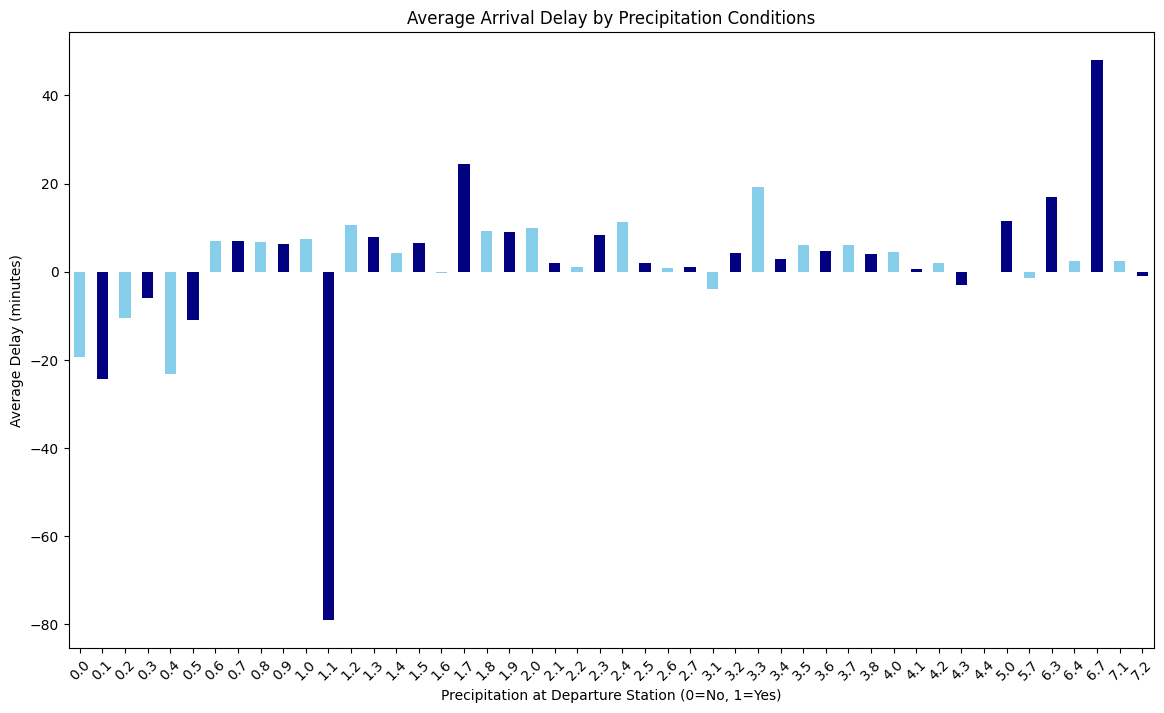

In [77]:
# rain vs average delay
plt.figure(figsize = (14,8))

rain_delay = df.groupby("from_precip")['arrival_delay_min'].mean()
rain_delay.plot(kind = 'bar', color= ['skyblue', 'navy'])
plt.title("Average Arrival Delay by Precipitation Conditions")
plt.xlabel("Precipitation at Departure Station (0=No, 1=Yes)")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()
# 0 is sky blue
# 1 is navy
# bar a 0 (sky blue) shows the average delays for trains that departed when it was not raining
# bar at 1 (navy) shows the average delays for trains that departed when it was raining.